In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from utils import get_partition_distances

In [2]:
splits = pd.read_csv("./data/1_random_kfolds/split.csv")
save_path = "./images/1_random_kfolds/"
print(splits.head(2)) 

DIST_PATH = "../data/rnadist_f_all.h5"
dist = pd.read_hdf(DIST_PATH)

   fold_number partition                                                 id
0            0     train                   tmRNA_Stre.gord._TRW-29390_1-349
1            0     train  tRNA_tdbR00000055-Schizosaccharomyces_pombe-48...


In [3]:
folds = splits.fold_number.unique()
folds.sort()

In [4]:
splits["partition"] = splits["partition"].apply(
    lambda x: "train" if x in ["train", "valid"] else "test"
)
parts = list(splits.partition.unique())

In [5]:
splits.partition.unique()

array(['train', 'test'], dtype=object)

In [6]:
parts = splits.partition.unique()
dfs = {fold : {s: {p: pd.DataFrame() for p in parts} for s in parts} for fold in folds}
for fold in folds:
    for p1 in parts:
        for p2 in parts:
            dfs[fold][p1][p2] = get_partition_distances(dist, splits, fold, p1, p2)
            print(f"Fold {fold} - {p1} vs {p2}: {dfs[fold][p1][p2].shape}")

Fold 0 - train vs train: (3091, 3091)
Fold 0 - train vs test: (3091, 773)
Fold 0 - test vs train: (773, 3091)
Fold 0 - test vs test: (773, 773)
Fold 1 - train vs train: (3092, 3092)
Fold 1 - train vs test: (3092, 772)
Fold 1 - test vs train: (772, 3092)
Fold 1 - test vs test: (772, 772)
Fold 2 - train vs train: (3091, 3091)
Fold 2 - train vs test: (3091, 773)
Fold 2 - test vs train: (773, 3091)
Fold 2 - test vs test: (773, 773)
Fold 3 - train vs train: (3091, 3091)
Fold 3 - train vs test: (3091, 773)
Fold 3 - test vs train: (773, 3091)
Fold 3 - test vs test: (773, 773)
Fold 4 - train vs train: (3091, 3091)
Fold 4 - train vs test: (3091, 773)
Fold 4 - test vs train: (773, 3091)
Fold 4 - test vs test: (773, 773)


In [7]:
def create_dfs(splits, verbose=False):
    # train = train + valid
    
    DIST_PATH = "../data/rnadist_f_all.h5"
    dist = pd.read_hdf(DIST_PATH)
    splits["partition"] = splits["partition"].apply(
    lambda x: "train" if x in ["train", "valid"] else "test"
    )
    folds = splits.fold_number.unique()
    parts = list(splits.partition.unique())
    
    dfs = {fold : {s: {p: pd.DataFrame() for p in parts} for s in parts} for fold in folds}
    for fold in folds:
        for p1 in parts:
            for p2 in parts:
                dfs[fold][p1][p2] = get_partition_distances(dist, splits, fold, p1, p2)
                if verbose:
                    print(f"Fold {fold} - {p1} vs {p2}: {dfs[fold][p1][p2].shape}")
    return dfs


In [8]:
dfs = create_dfs(splits, verbose=False)
dfs

{np.int64(0): {'train': {'train': id                                  16s_A.fulgidus_domain4  \
   id                                                           
   16s_A.fulgidus_domain4                            0.000000   
   16s_A.pyrophilus_domain2                          0.668000   
   16s_A.pyrophilus_domain4                          0.379562   
   16s_B.burgdorferi_domain2                         0.670487   
   16s_B.burgdorferi_domain3                         0.754639   
   ...                                                    ...   
   tmRNA_uncu.bact._TRW-72274-2_1-359                0.813370   
   tmRNA_uncu.bact._TRW-80840-1_1-378                0.822751   
   tmRNA_uncu.bact._TRW-80840-2_1-379                0.823219   
   tmRNA_uncu.bact._TRW-80840-3_1-379                0.828496   
   tmRNA_uncu.mari._TRW-363180_1-347                 0.829971   
   
   id                                  16s_A.pyrophilus_domain2  \
   id                                                

In [9]:
stats = {"fold": [], "min": [],"mean": [],"max": [] }
for fold in folds:
    A = dfs[fold]["train"]["test"].values
    stats["fold"].append(fold)
    stats["min"].append(np.nanmin(A))
    stats["mean"].append(np.nanmean(A))
    stats["max"].append(np.nanmax(A))
df_stats = pd.DataFrame(stats)
df_stats

,fold,min,mean,max
0,0,0.0,0.651768,1.40625
1,1,0.0,0.649804,1.40625
2,2,0.0,0.648594,1.40625
3,3,0.0,0.652924,1.40625
4,4,0.0,0.653372,1.40625


In [10]:
def create_stats(dfs, folds):
    stats = {"fold": [], "min": [],"mean": [],"max": [] }
    for fold in folds:
        A = dfs[fold]["train"]["test"].values
        stats["fold"].append(fold)
        stats["min"].append(np.nanmin(A))
        stats["mean"].append(np.nanmean(A))
        stats["max"].append(np.nanmax(A))
    df_stats = pd.DataFrame(stats)
    return df_stats

df_stats = create_stats(dfs, folds)
df_stats

,fold,min,mean,max
0,0,0.0,0.651768,1.40625
1,1,0.0,0.649804,1.40625
2,2,0.0,0.648594,1.40625
3,3,0.0,0.652924,1.40625
4,4,0.0,0.653372,1.40625


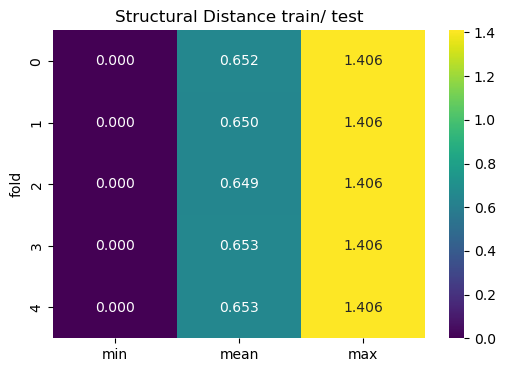

In [11]:

plt.figure(figsize=(6, 4))
sns.heatmap(
    df_stats.set_index("fold"),
    annot=True, fmt=".3f",
    cmap="viridis",
    vmin=0, vmax=1.41
)
plt.title("Structural Distance train/ test")
plt.ylabel("fold")
# plt.savefig(save_path+"heatmap_stats.pdf")
plt.show()


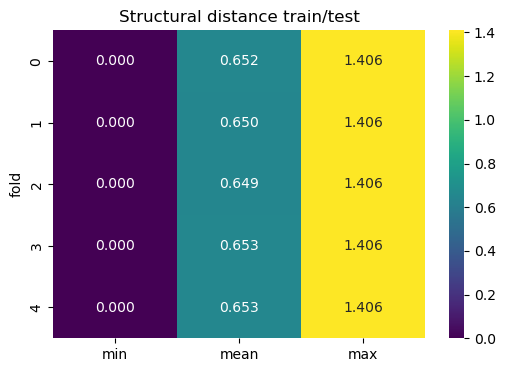

In [12]:
def plot_heatmap_stats(df_stats,index, save_path, SAVE=False):
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        df_stats.set_index(index),
        annot=True, fmt=".3f",
        cmap="viridis",
        vmin=0, vmax=1.41
    )
    plt.ylabel("fold")
    plt.title("Structural distance train/test")
    if SAVE:
        plt.savefig(save_path+"heatmap_stats.pdf")
    plt.show() 
plot_heatmap_stats(df_stats,index="fold",  save_path=save_path, SAVE=False)

<Axes: xlabel='id', ylabel='id'>

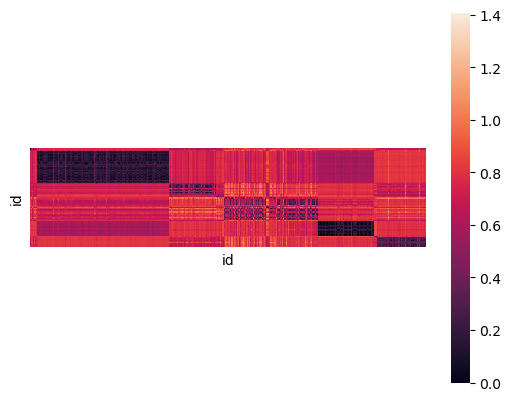

In [13]:
sns.heatmap(data=dfs[0]['test']['train'], square=True,
        xticklabels=False,
        yticklabels=False,)

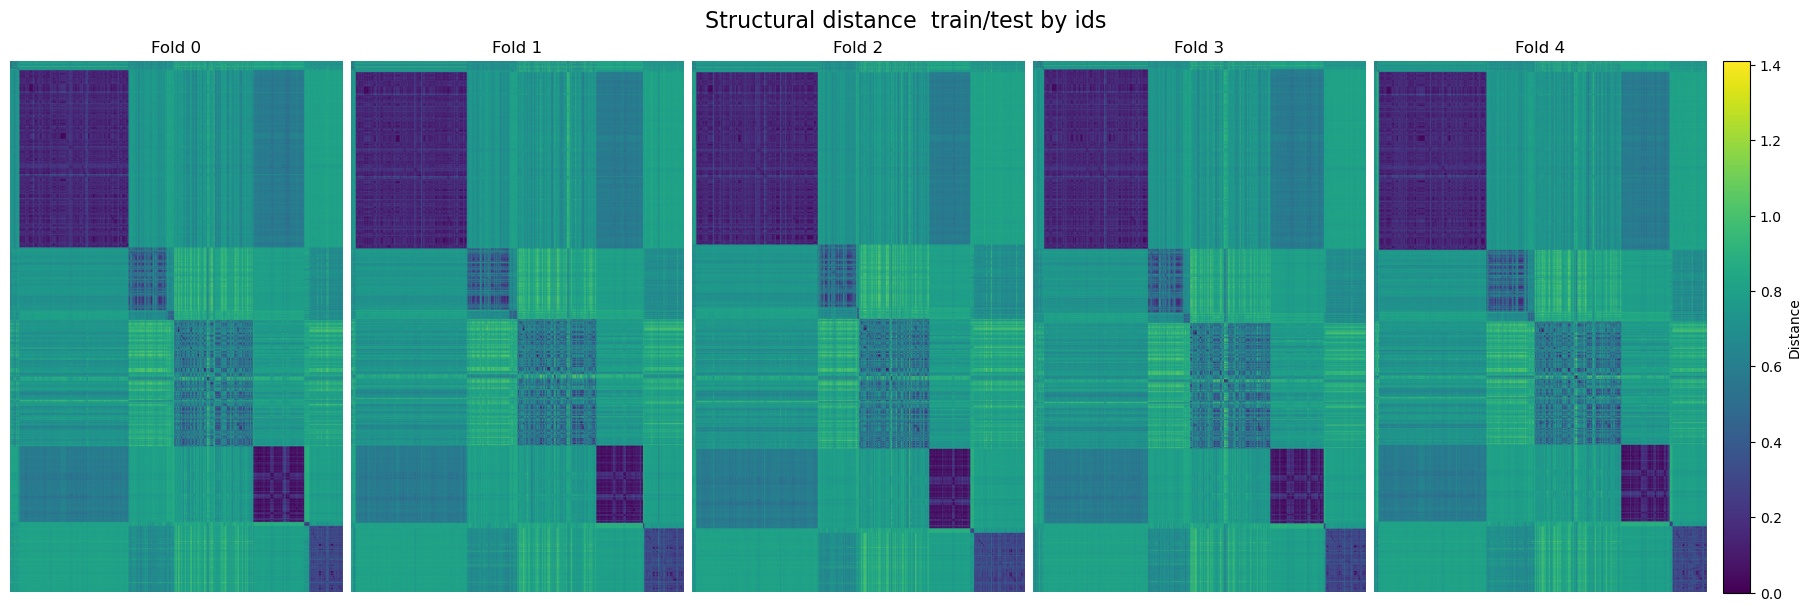

In [14]:
import matplotlib.pyplot as plt
import numpy as np

splits["fam"]=splits["id"].str.split("_").str[0]
id2fam = dict(zip(splits["id"], splits["fam"]))
fig, axes = plt.subplots(1, 5, figsize=(18, 6), constrained_layout=True)

vmin, vmax = 0, 1.41  # escala fija
for fold in range(5):
    mat = dfs[fold]['train']['test'].values
    im = axes[fold].imshow(mat, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
    axes[fold].set_title(f"Fold {fold}")
    axes[fold].axis('off')  # quita los ticks/labels

# agregar barra de color única
cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label("Distance")

plt.suptitle("Structural distance  train/test by ids", fontsize=16)
# plt.savefig(save_path+"heatmap_ids.pdf")
plt.show()


In [19]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# asignar familia a cada id
splits["fam"] = splits["id"].str.split("_").str[0]
id2fam = dict(zip(splits["id"], splits["fam"]))

# paleta de colores (tantos como familias distintas)
fams = sorted(set(id2fam.values()))
cmap = plt.cm.get_cmap("tab20", len(fams))
fam2color = {fam: cmap(i) for i, fam in enumerate(fams)}

/tmp/ipykernel_1331524/2669453185.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(fams))


/tmp/ipykernel_1331524/2751839933.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(fams))


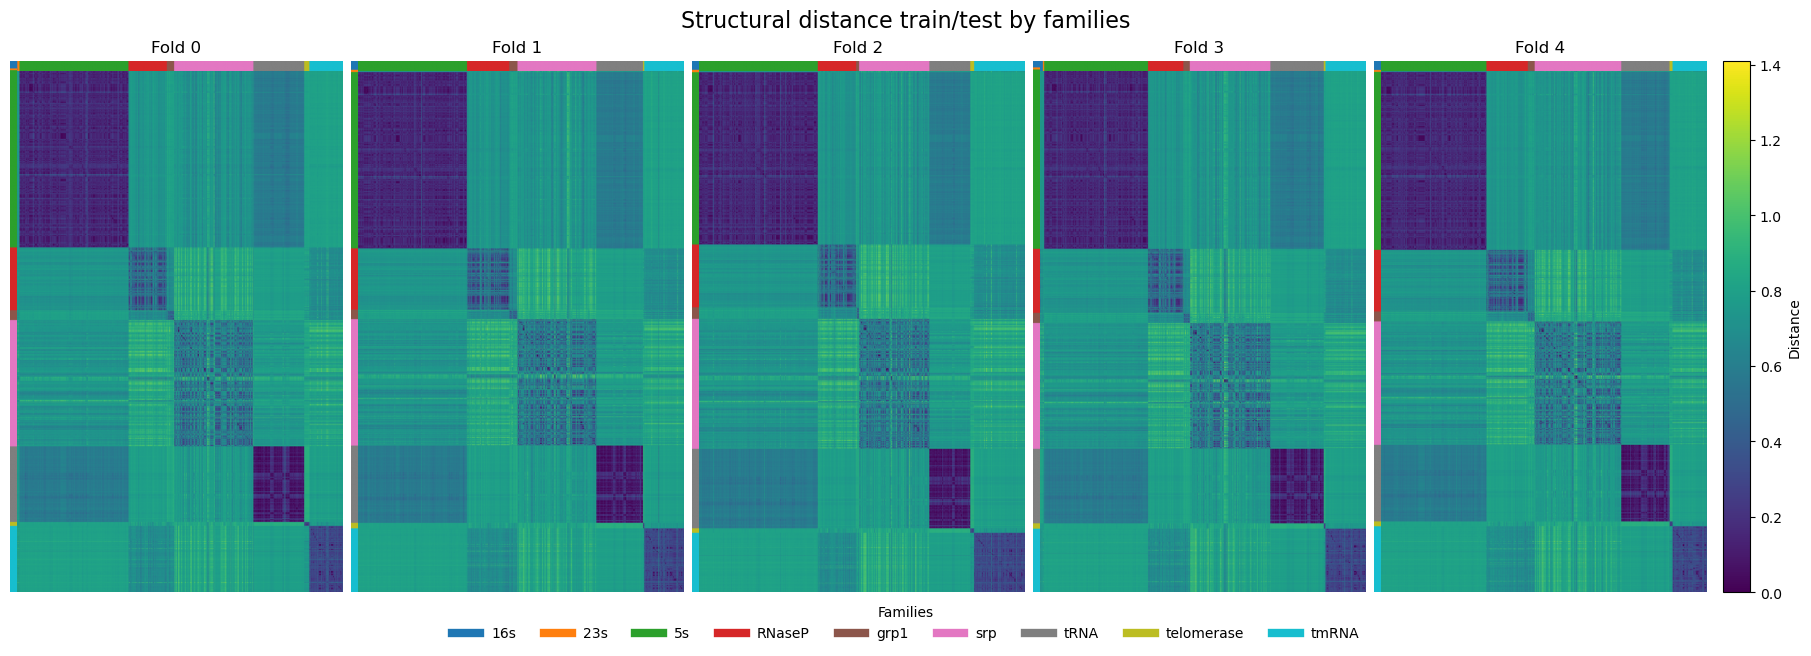

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# asignar familia a cada id
splits["fam"] = splits["id"].str.split("_").str[0]
id2fam = dict(zip(splits["id"], splits["fam"]))

# paleta de colores (Set3 es buena para categorías)
fams = sorted(set(id2fam.values()))
cmap = plt.cm.get_cmap("tab10", len(fams))
fam2color = {fam: cmap(i) for i, fam in enumerate(fams)}

fig, axes = plt.subplots(1, 5, figsize=(18, 6), constrained_layout=True)

vmin, vmax = 0, 1.41
for fold in range(5):
    mat = dfs[fold]['train']['test']  # dataframe con index/columns = ids
    im = axes[fold].imshow(mat.values, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
    axes[fold].set_title(f"Fold {fold}")
    axes[fold].axis("off")

    # familias filas y columnas → colores
    row_colors = [fam2color[id2fam[i]] for i in mat.index]
    col_colors = [fam2color[id2fam[i]] for i in mat.columns]

    # barrita arriba (columnas)
    ax_top = inset_axes(axes[fold], width="100%", height="2%", loc="upper center",
                        bbox_to_anchor=(0, 0, 1, 1), bbox_transform=axes[fold].transAxes, borderpad=0)
    ax_top.imshow([col_colors], aspect="auto")
    ax_top.axis("off")

    # barrita izquierda (filas)
    ax_left = inset_axes(axes[fold], width="2%", height="100%", loc="center left",
                         bbox_to_anchor=(0, 0, 1, 1), bbox_transform=axes[fold].transAxes, borderpad=0)
    ax_left.imshow(np.array(row_colors)[:, None].reshape(-1, 1, 4), aspect="auto")
    ax_left.axis("off")

# colorbar única para el heatmap
cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label("Distance")

# leyenda de familias
handles = [plt.Line2D([0], [0], color=fam2color[f], lw=6) for f in fams]
# leyenda abajo, centrada, con varias columnas
fig.legend(handles, fams, title="Families", bbox_to_anchor=(0.5, -0.08), loc='lower center', ncol=len(fams), frameon=False, fontsize=10)

plt.suptitle("Structural distance train/test by families", fontsize=16)
plt.show()


/tmp/ipykernel_1331524/2897804196.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(fams))


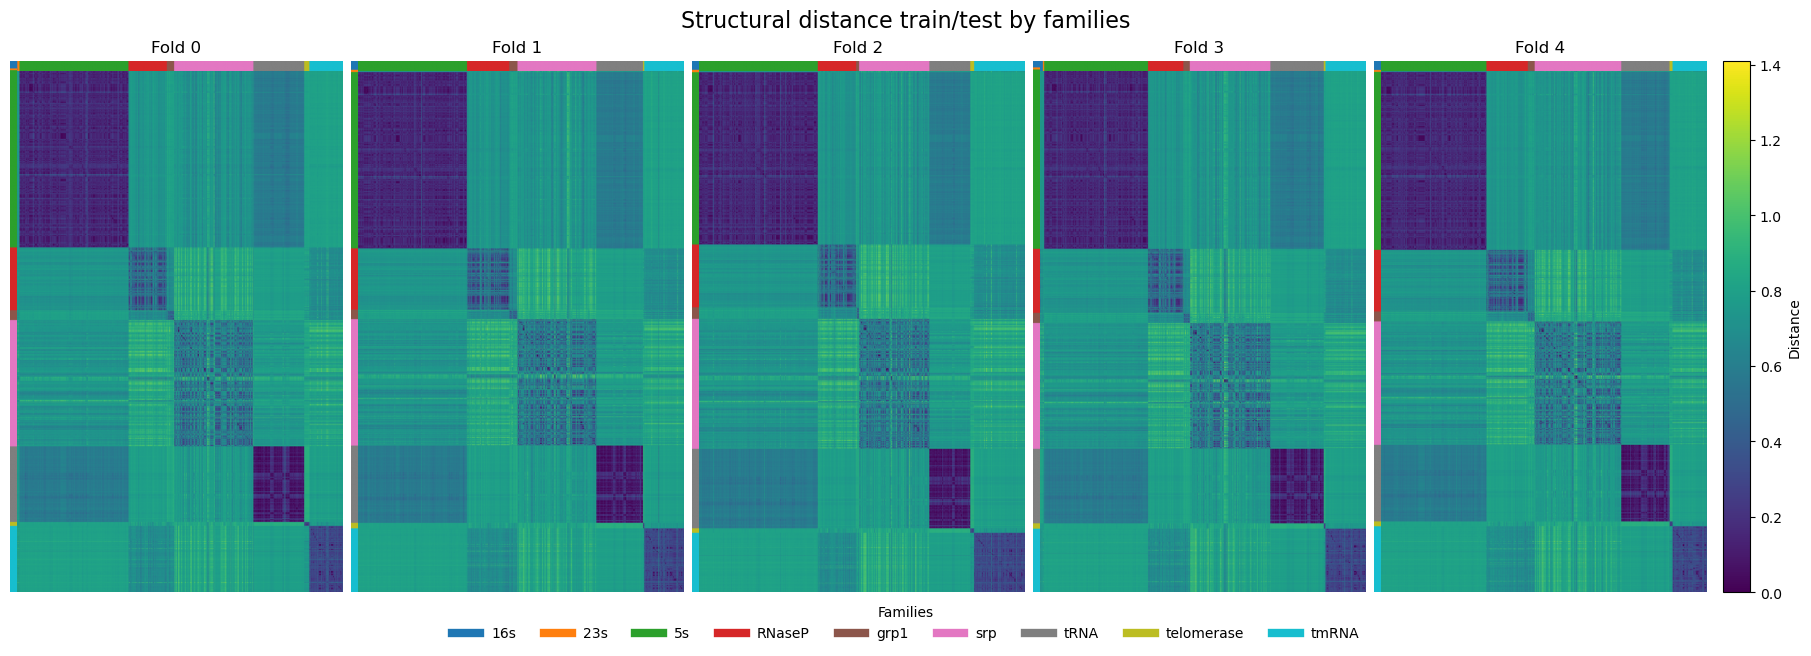

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def plot_heatmap_idsxfam(dfs, splits, save_path, SAVE=False):

    # asignar familia a cada id
    splits["fam"] = splits["id"].str.split("_").str[0]
    id2fam = dict(zip(splits["id"], splits["fam"]))

    # paleta de colores (Set3 es buena para categorías)
    fams = sorted(set(id2fam.values()))
    cmap = plt.cm.get_cmap("tab10", len(fams))
    fam2color = {fam: cmap(i) for i, fam in enumerate(fams)}

    fig, axes = plt.subplots(1, 5, figsize=(18, 6), constrained_layout=True)

    vmin, vmax = 0, 1.41
    for fold in range(len(dfs)):
        mat = dfs[fold]['train']['test']  # dataframe con index/columns = ids
        im = axes[fold].imshow(mat.values, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
        axes[fold].set_title(f"Fold {fold}")
        axes[fold].axis("off")

        # familias filas y columnas → colores
        row_colors = [fam2color[id2fam[i]] for i in mat.index]
        col_colors = [fam2color[id2fam[i]] for i in mat.columns]

        # barrita arriba (columnas)
        ax_top = inset_axes(axes[fold], width="100%", height="2%", loc="upper center",
                            bbox_to_anchor=(0, 0, 1, 1), bbox_transform=axes[fold].transAxes, borderpad=0)
        ax_top.imshow([col_colors], aspect="auto")
        ax_top.axis("off")

        # barrita izquierda (filas)
        ax_left = inset_axes(axes[fold], width="2%", height="100%", loc="center left",
                            bbox_to_anchor=(0, 0, 1, 1), bbox_transform=axes[fold].transAxes, borderpad=0)
        ax_left.imshow(np.array(row_colors)[:, None].reshape(-1, 1, 4), aspect="auto")
        ax_left.axis("off")

    # colorbar única para el heatmap
    cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.01)
    cbar.set_label("Distance")

    # leyenda de familias
    handles = [plt.Line2D([0], [0], color=fam2color[f], lw=6) for f in fams]
    # leyenda abajo, centrada, con varias columnas
    fig.legend(handles, fams, title="Families", bbox_to_anchor=(0.5, -0.08), loc='lower center', ncol=len(fams), frameon=False, fontsize=10)

    plt.suptitle("Structural distance train/test by families", fontsize=16)
    if SAVE:
        plt.savefig(save_path+"heatmap_ids.pdf")
    plt.show()

plot_heatmap_idsxfam(dfs, splits, save_path, SAVE=False)

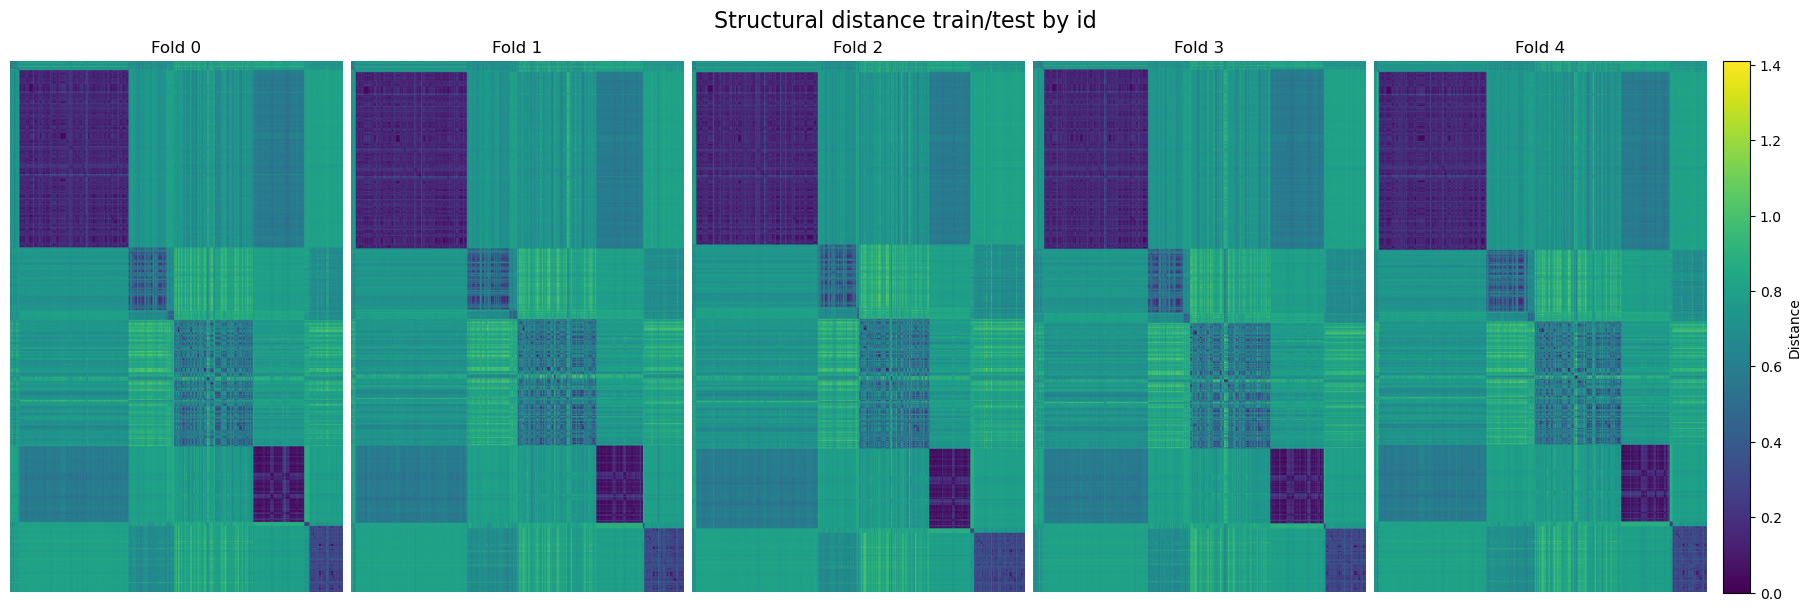

In [41]:
def plot_heatmap_ids(dfs, save_path, SAVE=False):

    fig, axes = plt.subplots(1, 5, figsize=(18, 6), constrained_layout=True)

    vmin, vmax = 0, 1.41  # escala fija
    for fold in range(5):
        mat = dfs[fold]['train']['test'].values
        im = axes[fold].imshow(mat, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
        axes[fold].set_title(f"Fold {fold}")
        axes[fold].axis('off')  # quita los ticks/labels

    # agregar barra de color única
    cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.01)
    cbar.set_label("Distance")

    plt.suptitle("Structural distance train/test by id", fontsize=16)
    if SAVE:
        plt.savefig(save_path+"heatmap_ids.pdf")
    plt.show()
    
    
plot_heatmap_ids(dfs, save_path, SAVE=False)

In [42]:
dfs_dists = {}
for fold in folds:
    rows = []
    mat = dfs[fold]['train']['test']
    vals = mat.to_numpy().ravel()
    rows.extend({ 
        "dist": float(v)
    } for v in vals)

    dfs_dists[fold] = pd.DataFrame(rows)


In [43]:
def create_flat_dfs(dfs, folds):
    dfs_dists = {}
    for fold in folds:
        rows = []
        mat = dfs[fold]['train']['test']
        vals = mat.to_numpy().ravel()
        rows.extend({ 
            "dist": float(v)
        } for v in vals)

        dfs_dists[fold] = pd.DataFrame(rows)
    return dfs_dists

create_flat_dfs(dfs, folds)
# ejemplo: muestro 5 filas
dfs_dists[0].sample(5)


,dist
2314900,0.812500
2373429,0.769231
1912541,0.593496
1949432,0.752113
16259,0.770661


In [44]:
# dfs_dists = {}

# for fold in folds:
#     rows = []
#     for part1, dic in dfs[fold].items():
#         for part2, mat in dic.items():
#             # solo analizamos train/test (part1 != part2)
#             if part1 != part2:
#                 vals = mat.to_numpy().ravel()
#                 rows.extend({
#                     "part1": part1,
#                     "part2": part2,
#                     "dist": float(v)
#                 } for v in vals)

#     dfs_dists[fold] = pd.DataFrame(rows)

# # ejemplo: muestro 5 filas
# dfs_dists[0].sample(5)


/tmp/ipykernel_1702288/2556077000.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', n_folds)
/tmp/ipykernel_1702288/2556077000.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


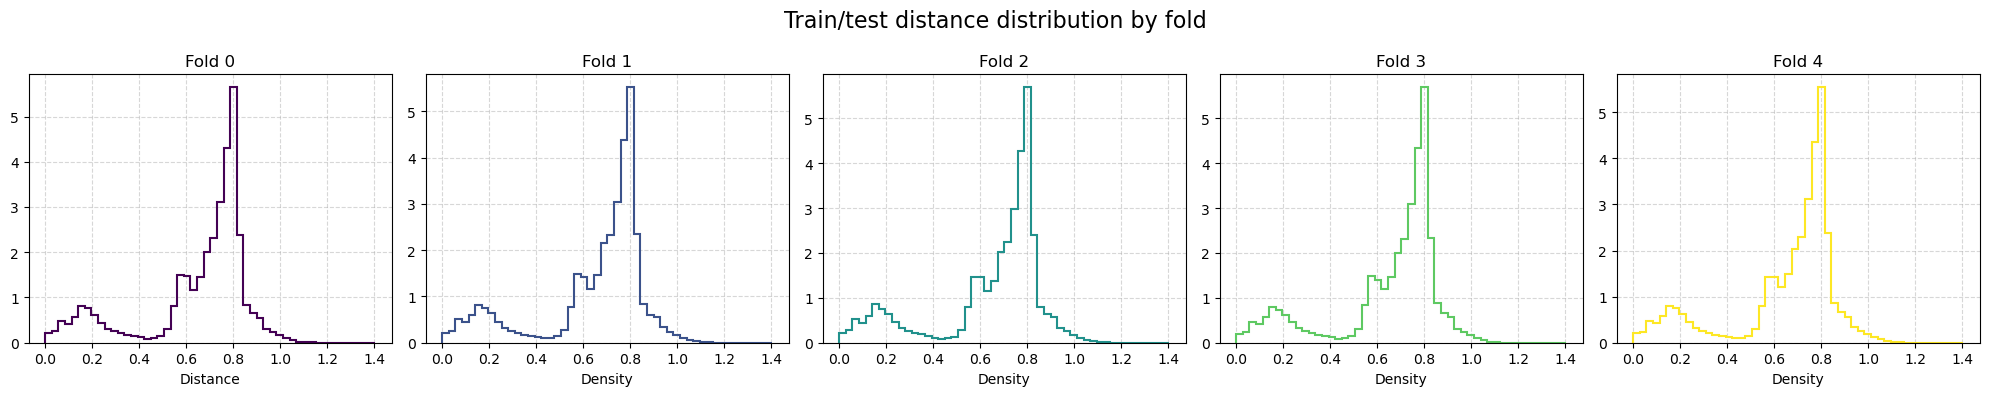

In [45]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm 

n_folds = len(folds)
cmap = cm.get_cmap('viridis', n_folds)
colors = [cmap(i) for i in range(n_folds)]

fig, axes = plt.subplots(1, n_folds, figsize=(20, 4), constrained_layout=True)

for i, fold in enumerate(folds):
    df = dfs_dists[fold]
    axes[i].hist(
        df['dist'],
        bins=50,
        density=True,
        histtype='step',
        color=colors[i],
        linewidth=1.5
    )
    axes[i].set_title(f"Fold {fold}")
    axes[i].set_ylabel("")
    axes[i].set_xlabel("Density")
    axes[i].grid(True, ls="--", alpha=0.5)

axes[0].set_xlabel("Distance")
plt.suptitle("Train/test distance distribution by fold", fontsize=16)
plt.tight_layout()
plt.savefig(save_path+"hist_subplots.pdf")
plt.show()

/tmp/ipykernel_1702288/1773246058.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', n_folds)
/tmp/ipykernel_1702288/1773246058.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


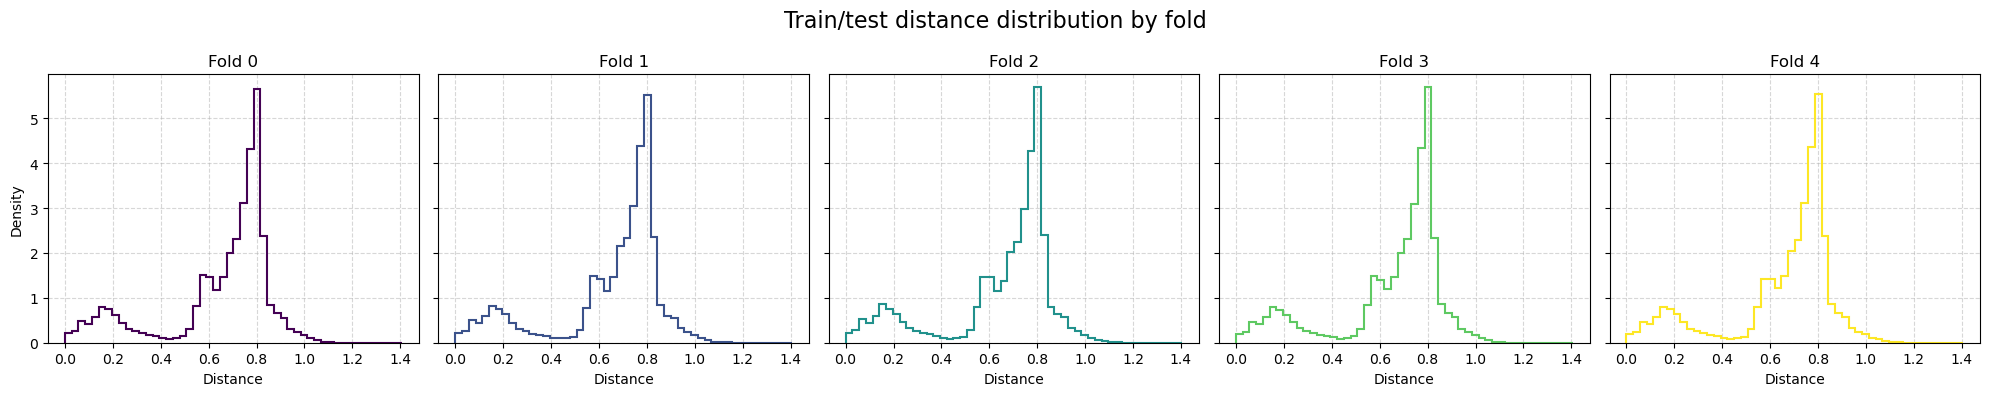

In [46]:
def plot_hist_subplots(dfs_dists, folds, save_path, SAVE=False):
    n_folds = len(folds)
    cmap = cm.get_cmap('viridis', n_folds)
    colors = [cmap(i) for i in range(n_folds)]

    fig, axes = plt.subplots(1, n_folds, figsize=(20, 4), constrained_layout=True, sharey=True, sharex=True)

    for i, fold in enumerate(folds):
        df = dfs_dists[fold]
        axes[i].hist(
            df['dist'],
            bins=50,
            density=True,
            histtype='step',
            color=colors[i],
            linewidth=1.5
        )
        axes[i].set_title(f"Fold {fold}")
        axes[i].set_xlabel("Distance")
        axes[i].set_ylabel("")
        axes[i].grid(True, ls="--", alpha=0.5)

    axes[0].set_ylabel("Density")
    plt.suptitle("Train/test distance distribution by fold", fontsize=16)
    plt.tight_layout()
    if SAVE:
        plt.savefig(save_path+"hist_subplots.pdf")
    plt.show()

plot_hist_subplots(dfs_dists, folds, save_path, SAVE=False)

/tmp/ipykernel_1702288/2917792558.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(folds))


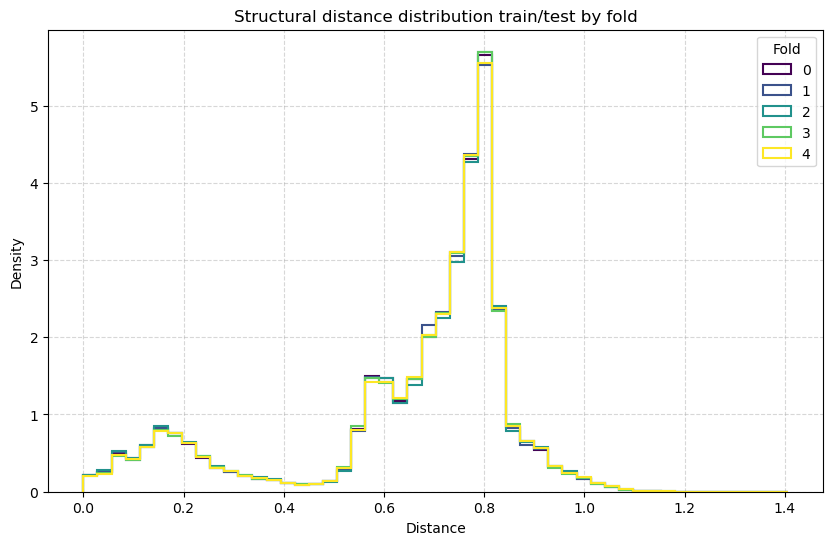

In [47]:
plt.figure(figsize=(10, 6))
# Genero colores de la paleta viridis
cmap = cm.get_cmap('viridis', len(folds))
colors = [cmap(i) for i in range(len(folds))]

for i, fold in enumerate(folds):
    df = dfs_dists[fold]
    plt.hist(
        df['dist'],
        bins=50,
        density=True,
        histtype='step',
        color=colors[i],
        linewidth=1.5,
        label=f"{fold}"
    )

plt.title("Structural distance distribution train/test by fold")
plt.xlabel("Distance")
plt.ylabel("Density")
plt.grid(True, ls="--", alpha=0.5)
plt.legend(title="Fold")

plt.savefig(save_path+"hist.pdf")
plt.show()


/tmp/ipykernel_1702288/2691315130.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(folds))


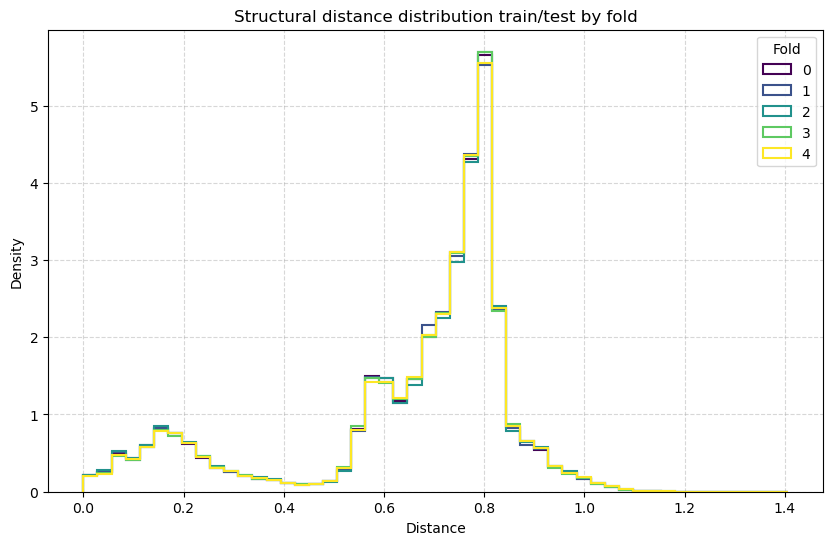

In [48]:
def plot_hist(dfs_dists, folds, save_path, SAVE=False):
    

    plt.figure(figsize=(10, 6))
    # Genero colores de la paleta viridis
    cmap = cm.get_cmap('viridis', len(folds))
    colors = [cmap(i) for i in range(len(folds))]

    for i, fold in enumerate(folds):
        df = dfs_dists[fold]
        plt.hist(
            df['dist'],
            bins=50,
            density=True,
            histtype='step',
            color=colors[i],
            linewidth=1.5,
            label=f"{fold}"
        )

    plt.title("Structural distance distribution train/test by fold")
    plt.xlabel("Distance")
    plt.ylabel("Density")
    plt.grid(True, ls="--", alpha=0.5)
    plt.legend(title="Fold")
    if SAVE:
        plt.savefig(save_path+"hist.pdf")
    plt.show()
plot_hist(dfs_dists, folds, save_path, SAVE=False)

/tmp/ipykernel_1702288/2011671705.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(folds))


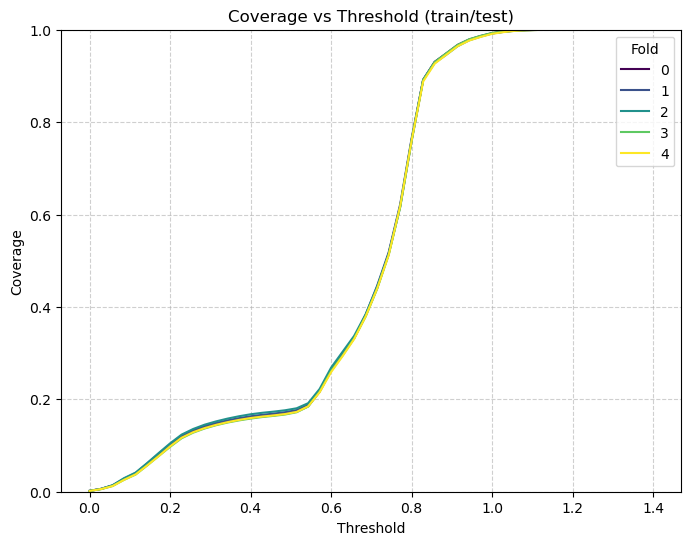

{np.int64(0): 0.17072182604171943, np.int64(1): 0.17435224781987949, np.int64(2): 0.17841850249210767, np.int64(3): 0.1694746212661807, np.int64(4): 0.17039746909506087}


In [49]:
thresholds = np.linspace(0, 1.4, 50)
cmap = cm.get_cmap('viridis', len(folds))
colors = [cmap(i) for i in range(len(folds))]

plt.figure(figsize=(8, 6))
cover_metric = {}
for i, fold in enumerate(folds):
    mat = dfs[fold]['train']['test']
    vals_dist = mat.values.ravel()
    cover_metric[fold] = (vals_dist <= 0.5).mean().item()
    coverage = [(vals_dist <= t).mean() for t in thresholds]
    plt.plot(
        thresholds,
        coverage,
        label=f"{fold}",
        color=colors[i]
    )

plt.title("Coverage vs Threshold (train/test)")
plt.xlabel("Threshold")
plt.ylabel("Coverage")
plt.grid(True, ls="--", alpha=0.6)
plt.ylim(0, 1)
plt.legend(title="Fold")
plt.savefig(save_path+"coverage.pdf")

plt.show()
print(cover_metric)

/tmp/ipykernel_1702288/2996042399.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(folds))


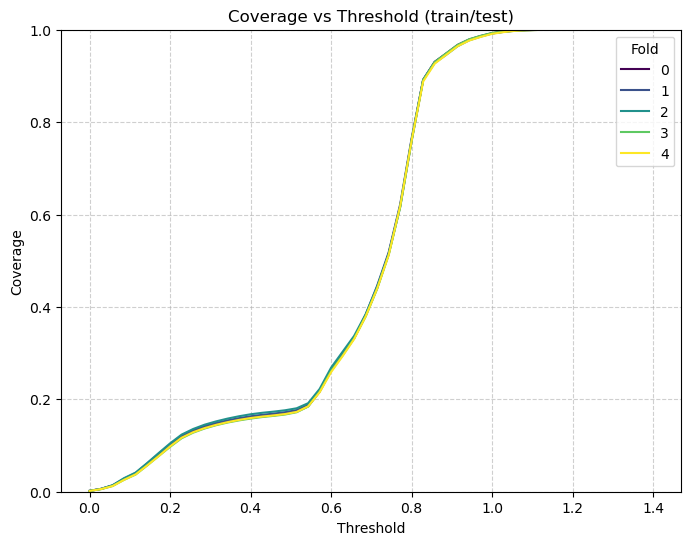

In [50]:
def plot_coverage(dfs, folds, save_path, SAVE=False):
    thresholds = np.linspace(0, 1.4, 50)
    cmap = cm.get_cmap('viridis', len(folds))
    colors = [cmap(i) for i in range(len(folds))]

    plt.figure(figsize=(8, 6))
    cover_metric = {}
    for i, fold in enumerate(folds):
        mat = dfs[fold]['train']['test']
        vals_dist = mat.values.ravel()
        cover_metric[fold] = (vals_dist <= 0.5).mean().item()
        coverage = [(vals_dist <= t).mean() for t in thresholds]
        plt.plot(
            thresholds,
            coverage,
            label=f"{fold}",
            color=colors[i]
        )

    plt.title("Coverage vs Threshold (train/test)")
    plt.xlabel("Threshold")
    plt.ylabel("Coverage")
    plt.grid(True, ls="--", alpha=0.6)
    plt.ylim(0, 1)
    plt.legend(title="Fold")
    if SAVE:
        plt.savefig(save_path+"coverage.pdf")

    plt.show() 
    
plot_coverage(dfs, folds, save_path, SAVE=False)